In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import glob
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import GroupKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

DATA_DIR = "/content/drive/MyDrive/data"
SELECTED_ACTIVITIES = ["sit", "walk", "run", "stairs"]
SELECTED_POSITIONS = ["dom_hand", "nondom_hand", "dom_pocket", "nondom_pocket", "backpack"]

SAMPLING_RATE = 100
TRIM_SECONDS = 2
WINDOW_SIZE = SAMPLING_RATE
STEP_SIZE = SAMPLING_RATE // 2

BATCH_SIZE = 32
EPOCHS = 100
LR = 0.001
DROPOUT = 0.3
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

RAW_FEATURES = ["ax", "ay", "az", "gx", "gy", "gz"]
GFT_FEATURES = ["ax_g", "ay_g", "az_g", "gx_g", "gy_g", "gz_g"]

In [3]:
def load_selected_csvs(base_dir):
    dfs = []
    for activity in SELECTED_ACTIVITIES:
        for position in SELECTED_POSITIONS:
            for csv_path in glob.glob(os.path.join(base_dir, activity, position, "*.csv")):
                df = pd.read_csv(csv_path)
                df["activity"] = activity
                df["phone_position"] = position
                df["recording_id"] = os.path.splitext(os.path.basename(csv_path))[0]
                dfs.append(df)
    print(f"CSV loading complete: {len(dfs)} recordings loaded")
    return dfs

def trim_df(df):
    trim = SAMPLING_RATE * TRIM_SECONDS
    if len(df) <= 2 * trim:
        return None
    return df.iloc[trim:-trim].reset_index(drop=True)

def sliding_windows(df):
    for start in range(0, len(df) - WINDOW_SIZE + 1, STEP_SIZE):
        yield df.iloc[start:start + WINDOW_SIZE]

class MotionDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def build_dataset(dfs, feature_cols):
    X, y, groups = [], [], []
    for df in dfs:
        df = trim_df(df)
        if df is None:
            continue
        for w in sliding_windows(df):
            X.append(w[feature_cols].values)
            y.append(w["activity"].iloc[0])
            groups.append(w["recording_id"].iloc[0])
    return np.array(X), np.array(y), np.array(groups)

In [4]:
class SinusoidalPositionalEmbedding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:x.size(1), :].unsqueeze(0)

class InvertedResidual(nn.Module):
    def __init__(self, inp, oup, stride=1, expand_ratio=4):
        super().__init__()
        hidden_dim = int(inp * expand_ratio)
        self.use_res_connect = (stride == 1 and inp == oup)
        layers = [
            nn.Conv1d(inp, hidden_dim, 1, bias=False),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Conv1d(hidden_dim, hidden_dim, 3, stride=stride, padding=1, groups=hidden_dim, bias=False),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Conv1d(hidden_dim, oup, 1, bias=False),
            nn.BatchNorm1d(oup)
        ]
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        if self.use_res_connect:
            return x + self.block(x)
        else:
            return self.block(x)

class MobileHARTBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = InvertedResidual(in_channels, out_channels)

    def forward(self, x):
        return self.block(x)

In [7]:
class MobileTransformer(nn.Module):
    def __init__(self, num_features, num_classes, dropout=0.3):
        super().__init__()
        self.acc_block = MobileHARTBlock(3, 32)
        self.gyro_block = MobileHARTBlock(3, 32)

        self.fusion_conv = nn.Conv1d(64, 64, kernel_size=1)
        self.bn_fusion = nn.BatchNorm1d(64)
        self.relu = nn.ReLU()

        self.pos_emb = SinusoidalPositionalEmbedding(d_model=64, max_len=WINDOW_SIZE)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=64, nhead=2, dim_feedforward=128, dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)

        self.gap = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
        acc = x[:, :, :3].permute(0, 2, 1)
        gyro = x[:, :, 3:].permute(0, 2, 1)

        acc_feat = self.acc_block(acc)
        gyro_feat = self.gyro_block(gyro)

        fused = torch.cat([acc_feat, gyro_feat], dim=1)
        fused = self.relu(self.bn_fusion(self.fusion_conv(fused)))
        fused = fused.permute(0, 2, 1)

        fused = self.pos_emb(fused)
        x_trans = self.transformer(fused)

        x_trans = x_trans.permute(0, 2, 1)
        x_pooled = self.gap(x_trans).squeeze(-1)
        x_pooled = self.dropout(x_pooled)
        return self.fc(x_pooled)

In [8]:
def train_fold(X_train, y_train, X_val, y_val, le, fold):
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train.reshape(-1, X_train.shape[-1])).reshape(X_train.shape)
    X_val = scaler.transform(X_val.reshape(-1, X_val.shape[-1])).reshape(X_val.shape)

    y_train = le.transform(y_train)
    y_val = le.transform(y_val)

    train_loader = DataLoader(MotionDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(MotionDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = MobileTransformer(num_features=X_train.shape[2],
                       num_classes=len(le.classes_),
                       dropout=DROPOUT).to(device)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=10)

    best_loss = np.inf
    best_state = None

    for epoch in range(1, EPOCHS + 1):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

        model.eval()
        val_loss = 0
        preds_all, true_all = [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb)
                loss = criterion(preds, yb)
                val_loss += loss.item() * xb.size(0)
                preds_all.extend(preds.argmax(1).cpu().numpy())
                true_all.extend(yb.cpu().numpy())
        val_loss /= len(val_loader.dataset)
        acc = accuracy_score(true_all, preds_all)
        scheduler.step(val_loss)

        if epoch % 10 == 0:
            print(f"Fold {fold} | Epoch {epoch} | Val Loss {val_loss:.4f} | Val Acc {acc:.4f}")

        if val_loss < best_loss:
            best_loss = val_loss
            best_state = model.state_dict()

    model.load_state_dict(best_state)
    return model, true_all, preds_all

def evaluateTransformer(X, y, groups, title):
    le = LabelEncoder()
    le.fit(y)

    gkf = GroupKFold(n_splits=5)
    y_true_all, y_pred_all = [], []

    for fold, (tr, va) in enumerate(gkf.split(X, y, groups), 1):
        print(f"\n=== Fold {fold} ===")
        model, yt, yp = train_fold(X[tr], y[tr], X[va], y[va], le, fold)
        y_true_all.extend(yt)
        y_pred_all.extend(yp)

    print(f"\n=== {title} ===")
    print(classification_report(y_true_all, y_pred_all, target_names=le.classes_, digits=4))

    cm = confusion_matrix(y_true_all, y_pred_all)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=le.classes_,
                yticklabels=le.classes_,
                cmap="Oranges")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.show()

CSV loading complete: 100 recordings loaded

=== Fold 1 ===
Fold 1 | Epoch 10 | Val Loss 0.5050 | Val Acc 0.9363
Fold 1 | Epoch 20 | Val Loss 0.5289 | Val Acc 0.9234
Fold 1 | Epoch 30 | Val Loss 0.4827 | Val Acc 0.9493
Fold 1 | Epoch 40 | Val Loss 0.4967 | Val Acc 0.9463
Fold 1 | Epoch 50 | Val Loss 0.4711 | Val Acc 0.9562
Fold 1 | Epoch 60 | Val Loss 0.4961 | Val Acc 0.9493
Fold 1 | Epoch 70 | Val Loss 0.4755 | Val Acc 0.9552
Fold 1 | Epoch 80 | Val Loss 0.4726 | Val Acc 0.9582
Fold 1 | Epoch 90 | Val Loss 0.4962 | Val Acc 0.9522
Fold 1 | Epoch 100 | Val Loss 0.4671 | Val Acc 0.9562

=== Fold 2 ===
Fold 2 | Epoch 10 | Val Loss 0.4531 | Val Acc 0.9582
Fold 2 | Epoch 20 | Val Loss 0.4318 | Val Acc 0.9721
Fold 2 | Epoch 30 | Val Loss 0.4146 | Val Acc 0.9731
Fold 2 | Epoch 40 | Val Loss 0.4126 | Val Acc 0.9761
Fold 2 | Epoch 50 | Val Loss 0.4336 | Val Acc 0.9721
Fold 2 | Epoch 60 | Val Loss 0.4252 | Val Acc 0.9731
Fold 2 | Epoch 70 | Val Loss 0.4178 | Val Acc 0.9771
Fold 2 | Epoch 80 | Va

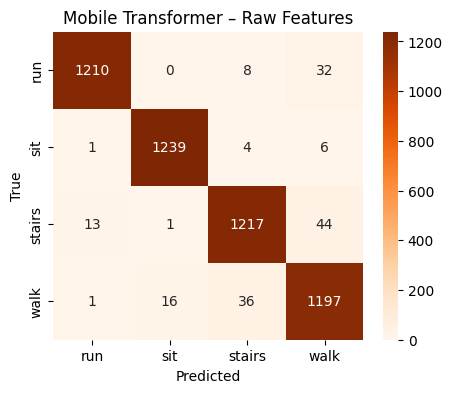


=== Fold 1 ===
Fold 1 | Epoch 10 | Val Loss 0.4736 | Val Acc 0.9493
Fold 1 | Epoch 20 | Val Loss 0.4690 | Val Acc 0.9572
Fold 1 | Epoch 30 | Val Loss 0.4469 | Val Acc 0.9672
Fold 1 | Epoch 40 | Val Loss 0.4938 | Val Acc 0.9473
Fold 1 | Epoch 50 | Val Loss 0.4671 | Val Acc 0.9552
Fold 1 | Epoch 60 | Val Loss 0.4602 | Val Acc 0.9572
Fold 1 | Epoch 70 | Val Loss 0.4685 | Val Acc 0.9542
Fold 1 | Epoch 80 | Val Loss 0.4738 | Val Acc 0.9522
Fold 1 | Epoch 90 | Val Loss 0.4761 | Val Acc 0.9542
Fold 1 | Epoch 100 | Val Loss 0.4824 | Val Acc 0.9463

=== Fold 2 ===
Fold 2 | Epoch 10 | Val Loss 0.6022 | Val Acc 0.8796
Fold 2 | Epoch 20 | Val Loss 0.5685 | Val Acc 0.9055
Fold 2 | Epoch 30 | Val Loss 0.5879 | Val Acc 0.8965
Fold 2 | Epoch 40 | Val Loss 0.6074 | Val Acc 0.8965
Fold 2 | Epoch 50 | Val Loss 0.6123 | Val Acc 0.8935
Fold 2 | Epoch 60 | Val Loss 0.5921 | Val Acc 0.9104
Fold 2 | Epoch 70 | Val Loss 0.6070 | Val Acc 0.8995
Fold 2 | Epoch 80 | Val Loss 0.5960 | Val Acc 0.9035
Fold 2 | Epoc

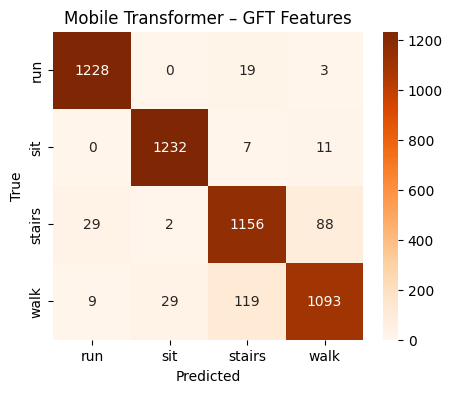

In [9]:
if __name__ == "__main__":
    recordings = load_selected_csvs(DATA_DIR)

    X_raw, y_raw, g_raw = build_dataset(recordings, RAW_FEATURES)
    evaluateTransformer(X_raw, y_raw, g_raw, "Mobile Transformer – Raw Features")

    X_gft, y_gft, g_gft = build_dataset(recordings, GFT_FEATURES)
    evaluateTransformer(X_gft, y_gft, g_gft, "Mobile Transformer – GFT Features")